This notebook is used for:
- training a LSTM-based rainfall-runoff modeling

In [1]:
import pandas as pd

import jax
import jax.numpy as jnp
import jax.random as jrandom
import jax.tree_util as jtu
from jaxtyping import Array, PRNGKeyArray

import equinox as eqx

import optax

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from DiffFlowTransport.flow import LSTM
from DiffFlowTransport.utils import compute_metrics, mse
from DiffFlowTransport.utils import train_dl, evaluate_dl, predict_dl
from DiffFlowTransport.utils import make_pytorch_timeseries_dataloader
from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload


# Read the data

In [2]:
df = pd.read_csv('./data.csv', index_col=1)
df.index = pd.to_datetime(df.index, format='%m/%d/%y')
df.head()


,timestep,J,Cl mg/l,Q,ET,Q Cl mg/l,S_scale
datetime,,,,,,,
1983-05-03,0,0.25,1.643836,3.404765,3.279204,NaN,4675.943543
1983-05-04,1,0.00,0.000000,3.032749,2.572585,NaN,4909.717786
1983-05-05,2,6.25,1.643836,2.954061,0.882162,NaN,4979.097380
1983-05-06,3,11.75,1.643836,3.821581,1.653902,NaN,4471.583891
1983-05-07,4,11.25,1.643836,5.064662,0.994315,NaN,3957.744963


# Data preprocessing

## Data normalization

In [3]:
scaler, df_norm = {}, df.copy()

for varn in df.columns:
    # scaler_v = StandardScaler()
    scaler_v = MinMaxScaler()
    df_norm[varn] = scaler_v.fit_transform(df[[varn]].values)
    scaler[varn] = scaler_v

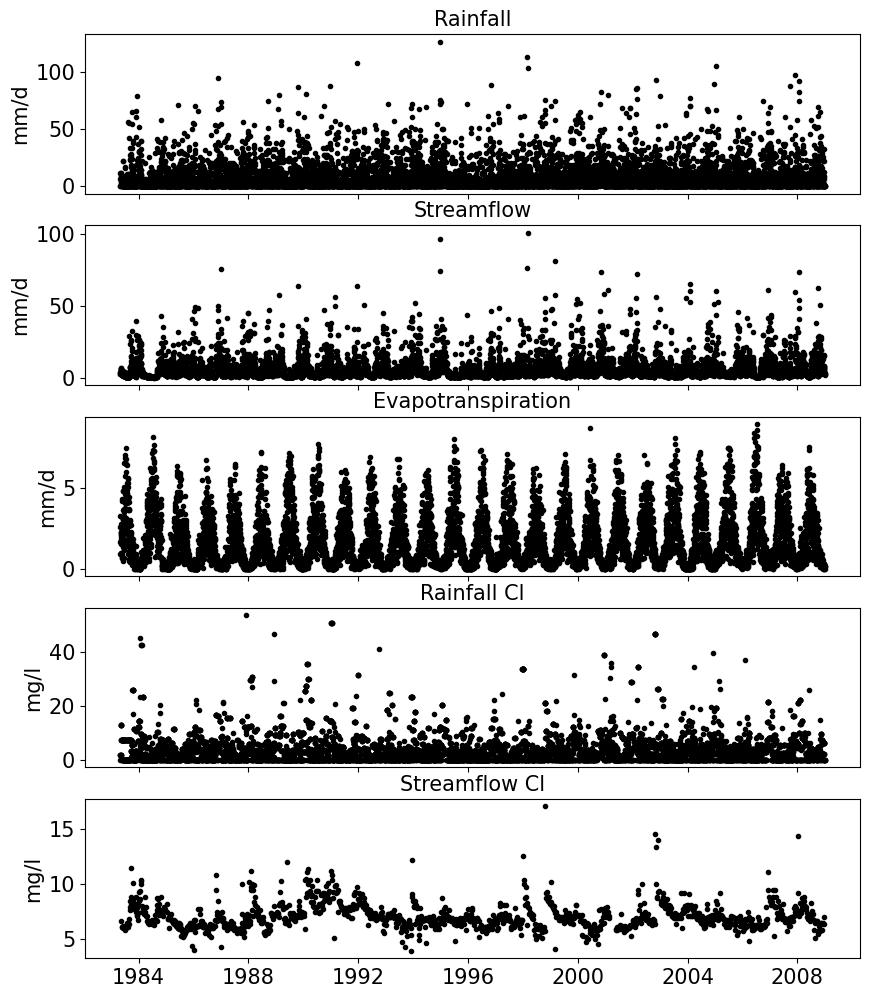

In [26]:
# varns = df_norm.keys().to_list()
varns = ['J', 'Q', 'ET', 'Cl mg/l', 'Q Cl mg/l']
varn_labels = ['Rainfall', 'Streamflow', 'Evapotranspiration', 'Rainfall Cl', 'Streamflow Cl']
units = ['mm/d', 'mm/d', 'mm/d', 'mg/l', 'mg/l']
fig, axes = plt.subplots(5, 1, figsize=(10,12), sharex=True)
for i,ax in enumerate(axes):
    varn = varns[i]
    # df_norm[varn].plot(ax=ax)
    ax.plot(df.index, df[varn].values, 'k.')
    ax.set(title=varn_labels[i], ylabel=units[i])

## Split the data into training and test sets

In [5]:
# Separate training and test sets
train_start, train_end = '1983-01-01', '1998-12-31'
test_start, test_end = '1999-01-01', '2008-12-31'

# divide dataset in training and test set
df_norm_train = df_norm.loc[train_start:train_end].copy()
df_norm_test = df_norm.loc[test_start:test_end].copy()

# print fraction the test set is of all the used data
print('Test set fraction: ', len(df_norm_test) / (len(df_norm_train) + len(df_norm_test)))


Test set fraction:  0.38965333333333335


# Rainfall-Runoff modeling

## Configuration

In [6]:
# Model output variable
target   = 'Q'

# Model input feature
features = ['J']
# features = ['P']

# DL model configuration and training settings
sequence_length = 365
batch_size = 512
learning_rate = 0.001
hidden_size = 20
epochs = 100

# Random keys
data_key, model_key = jrandom.split(jrandom.PRNGKey(1024), 2)


INFO:2025-01-28 11:43:04,283:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-01-28 11:43:04,283 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-01-28 11:43:04,284:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/jian449/anaconda3/envs/nn-flow-transport/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
2025-01-28 11:43:04,284 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volume

## Get the dataloader

In [17]:
train_loader = make_pytorch_timeseries_dataloader(
    df_norm_train, target, features, sequence_length, batch_size, shuffle=True
)

train_eval_loader = make_pytorch_timeseries_dataloader(
    df_norm_train, target, features, sequence_length, batch_size, shuffle=False
)

test_loader = make_pytorch_timeseries_dataloader(
    df_norm_test, target, features, sequence_length, batch_size, shuffle=False
)

all_loader = make_pytorch_timeseries_dataloader(
    df_norm, target, features, sequence_length, batch_size, shuffle=False
)


## Initialize the LSTM model

In [8]:
model = LSTM(in_size=len(features), out_size=1, hidden_size=hidden_size, key=model_key)
model


LSTM(
  hidden_size=20,
  cell=LSTMCell(
    weight_ih=f32[80,1],
    weight_hh=f32[80,20],
    bias=None,
    input_size=1,
    hidden_size=20,
    use_bias=False
  ),
  linear=Linear(
    weight=f32[1,20],
    bias=f32[1],
    in_features=20,
    out_features=1,
    use_bias=True
  )
)

## Train the model

In [9]:
filter_model_spec = jtu.tree_map(lambda _: True, model)

In [10]:
optim = optax.adamw(learning_rate)
model, loss_train, loss_test = train_dl(
    model, filter_model_spec, epochs, mse, optim, train_loader, test_loader
)



Epoch 0
-----
Training loss: 0.005080345552414656
Test loss: 0.006019743625074625


Epoch 1
-----
Training loss: 0.004811432678252459
Test loss: 0.005702247377485037


Epoch 2
-----
Training loss: 0.004639089107513428
Test loss: 0.005393214523792267


Epoch 3
-----
Training loss: 0.004530526231974363
Test loss: 0.00501105934381485


Epoch 4
-----
Training loss: 0.004126513842493296
Test loss: 0.0045573050156235695


Epoch 5
-----
Training loss: 0.003715828061103821
Test loss: 0.004052741918712854


Epoch 6
-----
Training loss: 0.0031960695050656796
Test loss: 0.0034818225540220737


Epoch 7
-----
Training loss: 0.002741341944783926
Test loss: 0.0031127824913710356


Epoch 8
-----
Training loss: 0.0025297431275248528
Test loss: 0.0029077890794724226


Epoch 9
-----
Training loss: 0.0023905227426439524
Test loss: 0.002712392946705222


Epoch 10
-----
Training loss: 0.0021874443627893925
Test loss: 0.00252694939263165


Epoch 11
-----
Training loss: 0.0020728183444589376
Test loss: 0.00

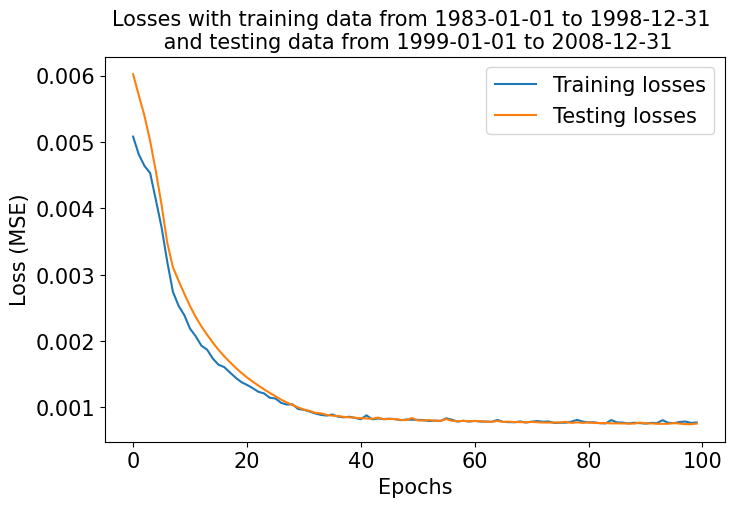

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(loss_train, label='Training losses')
ax.plot(loss_test, label='Testing losses')
ax.set(title=f'Losses with training data from {train_start} to {train_end} \n and testing data from {test_start} to {test_end}',
       ylabel='Loss (MSE)', xlabel='Epochs')
ax.legend(loc='upper right');


# Prediction

In [12]:
# def predict_dl(data_loader, model):
#     # initiaze output data
#     y_pred_set = []

#     # iterate through data from data loader and make prediction
#     for i, (x,y) in enumerate(data_loader):
#         x, y = jnp.array(x), jnp.array(y)
#         y_pred = jax.vmap(model)(x)
#         # y_pred_set.append(ht_pred[:,-1])
#         y_pred_set.append(y_pred)
    
#     return jnp.concatenate(y_pred_set, 0)

In [18]:
# predict data with model
y_pred = predict_dl(all_loader, model)

# make placeholder for model output data
y_pred_col = 'LSTM'

# load data in dataframe
df_out = pd.DataFrame(index=df_norm.index[sequence_length:],
                            data={target:df_norm[target][sequence_length:],
                                  y_pred_col:y_pred.flatten()})
# de-normalize data
for col in df_out.columns:
    df_out[col] = scaler[target].inverse_transform(df_out[[col]].values)


(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Rainfall-Runoff Modeling'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 5.783; NSE: 0.409)'}, xlabel='Observation', ylabel='Simulation'>)

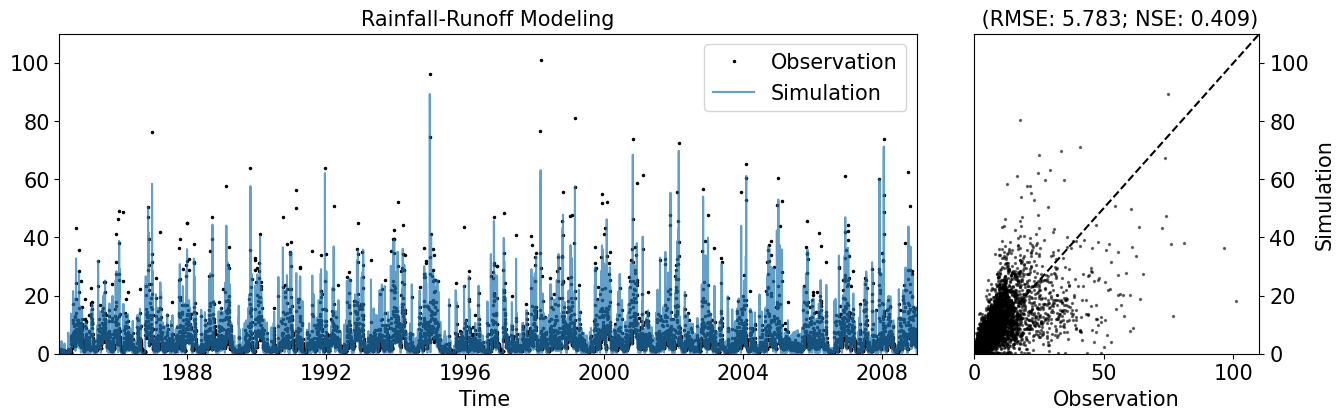

In [19]:
plot_timeseries_obs_1to1(
    obs=df_out['Q'].values, sim=df_out['LSTM'].values, 
    lim=[0.,110.], 
    timesteps=df_out.index,
    varn='Rainfall-Runoff Modeling'
)

# plot_timeseries_obs_1to1(
#     obs=df['Q Cl mg/l'].values, sim=df['C_Q InvariantGamma'].values, lim=[2,15], timesteps=df.index,
#     varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
# )


In [27]:
# df_train_out